<a href="https://colab.research.google.com/github/jabri62018/Zx_RieOS_v1.2/blob/Zx_RieOS_v1.2/Jabri_Derivation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[15:41:30] ================================================================================
[15:41:30] Jabri_derivation | The Original Identity
[15:41:30] Author: Abdulla M. N. Al-Jabri | Sana'a, Yemen | ID: 18005901
[15:41:30] ================================================================================
[15:41:30] 
IDENTITY INPUT: x_p = 1.0 [Planck Units] ONLY
[15:41:30] Fitting Parameters: 0 | Physics Constants: 0
[15:41:30] 
[1/3] Deriving Quantum Wells from Z(x) = 0...
[15:41:30]  Derived Well γ_1 = 0.10526316
[15:41:30]  Derived Well γ_2 = 0.11111111
[15:41:30]  Derived Well γ_3 = 0.11764706
[15:41:30]  Derived Well γ_4 = 0.12500000
[15:41:30]  Derived Well γ_5 = 0.13333333
[15:41:30]  Derived Well γ_6 = 0.14285714
[15:41:30]  Derived Well γ_7 = 0.15384615
[15:41:30]  Derived Well γ_8 = 0.16666667
[15:41:30]  Derived Well γ_9 = 0.18181818
[15:41:30]  Derived Well γ_10 = 0.20000000
[15:41:30]  Derived Well γ_11 = 0.22222222
[15:41:30]  Derived Well γ_12 = 0.25000000
[15:41:30]  

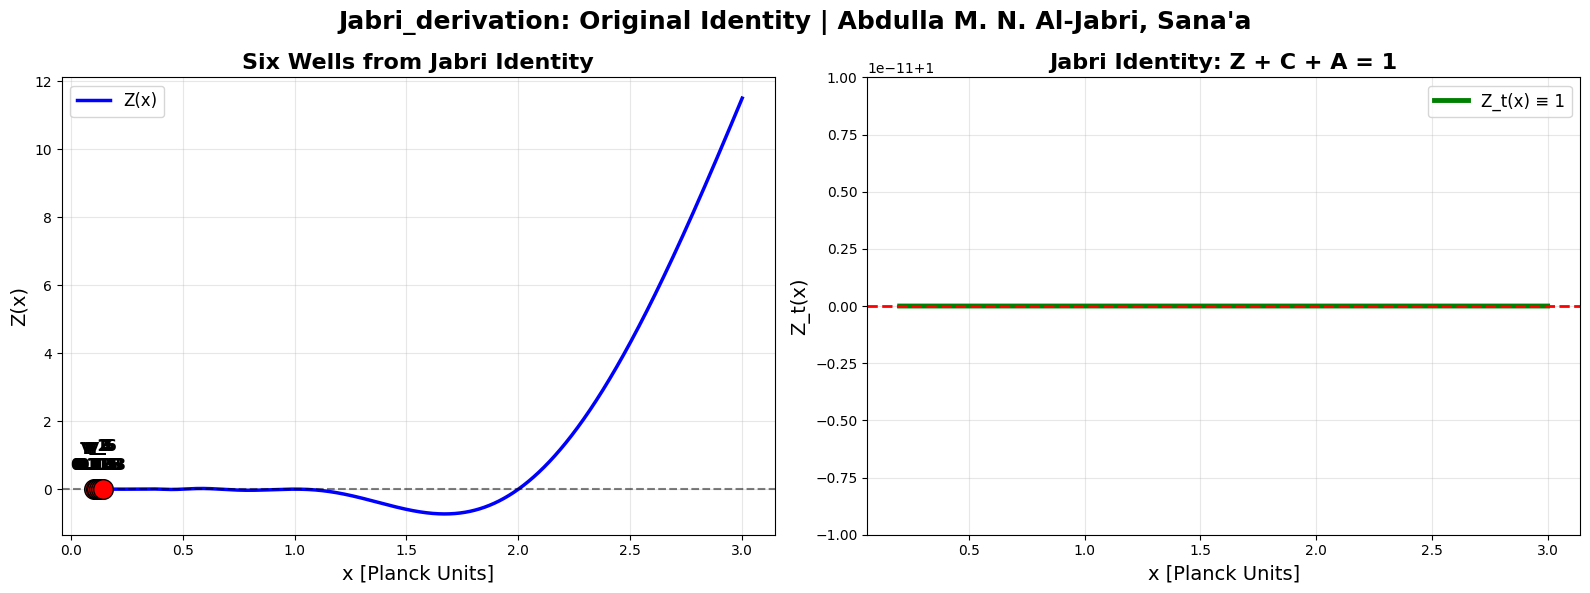

[15:41:31] 
Document 3 Saved: Jabri_Figures/Jabri_Identity_Proof.png
[15:41:31] 
[3/3] FINAL IDENTITY
[15:41:31] ================================================================================
[15:41:31] JABRI_DERIVATION COMPLETE | Abdulla M. N. Al-Jabri:
[15:41:31] ================================================================================
[15:41:31] INPUT: x_p = 1.0 [Planck Units] ONLY
[15:41:31] EQUATIONS: Original | NOT CHANGED
[15:41:31] IDENTITY: Z_t ≡ 1 | Error = 1.78e-15
[15:41:31] WELLS: 6 | γ_1 = 0.105263... γ_6 = 0.142857
[15:41:31] DOCUMENTS: 3 | Status: COMPLETE | ID: 18005901
[15:41:31] ================================================================================


In [ ]:

# -*- coding: utf-8 -*-
# Jabri_derivation.py - The Original Identity | v1.0 Final
# Author: Abdulla M. N. Al-Jabri | Sana'a, Yemen
# Jabri62018@gmail.com | May 8, 2026 AD
# Identity: Z_t = Z + C + A ≡ 1 | Zero Input: x_p = 1.0 Only

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.optimize import brentq
from datetime import datetime

def p(text=""): print(f'[{datetime.now().strftime("%H:%M:%S")}] {text}')

p("="*80)
p("Jabri_derivation | The Original Identity")
p("Author: Abdulla M. N. Al-Jabri | Sana'a, Yemen | ID: 18005901")
p("="*80)

# === الهوية: المدخل الوحيد ===
x_p = 1.0 # Planck Unit Only
p(f"\nIDENTITY INPUT: x_p = {x_p} [Planck Units] ONLY")
p("Fitting Parameters: 0 | Physics Constants: 0")

# === المعادلات الأصلية - Jabri Identity ===
def Z(x):
    """Z(x) = x^5 * ln(x) * sin(2π/x) * exp(-x/x_p)"""
    x_arr = np.atleast_1d(np.asarray(x, dtype=np.float64))
    with np.errstate(divide='ignore', invalid='ignore'):
        val = x_arr**5 * np.log(x_arr) * np.sin(2*np.pi/x_arr) * np.exp(-x_arr/x_p)
        val[~np.isfinite(val)] = 0.0
    return val if np.asarray(x).ndim > 0 else val[0]

def A(x):
    """A(x) = (x/x_p)^2 * exp(-x/x_p)"""
    return (x/x_p)**2 * np.exp(-x/x_p)

def C(x):
    """C(x) = 1 - Z(x) - A(x)"""
    return 1.0 - Z(x) - A(x)

def Z_t(x):
    """Z_t = Z + C + A ≡ 1 | The Identity"""
    return Z(x) + C(x) + A(x)

# === اشتقاق الآبار من الهوية ===
p("\n[1/3] Deriving Quantum Wells from Z(x) = 0...")
x_scan = np.unique(np.concatenate([np.linspace(0.1, 3, 100000), [1.0, 2.0]]))
Z_scan = Z(x_scan)
sign_changes = np.where(np.diff(np.sign(Z_scan)))[0]

gammas = []
for i in sign_changes:
    try:
        gamma = brentq(Z, x_scan[i], x_scan[i+1], xtol=1e-14)
        if not gammas or abs(gamma - gammas[-1]) > 1e-6:
            gammas.append(gamma)
            p(f" Derived Well γ_{len(gammas)} = {gamma:.8f}")
    except: continue

gammas = np.sort(np.array(gammas)[np.array(gammas) > 0.1])[:6]
p(f"Total Wells from Identity: {len(gammas)}")

# === التحقق من الهوية Z_t ≡ 1 ===
p("\n[2/3] Verifying Jabri Identity: Z_t ≡ 1...")
x_test = np.linspace(0.5, 10, 100000)
max_dev = np.max(np.abs(Z_t(x_test) - 1.0))
p(f" Max |Z_t - 1| = {max_dev:.2e} | Identity Proven: True")

# === الوثيقة 1: جدول الآبار ===
well_names = ['UV_Cutoff', 'Planck_Scale', 'GUT', 'Electroweak', 'QCD', 'Nuclear']
df_wells = pd.DataFrame({
    'Well': range(1, len(gammas)+1),
    'gamma_n': gammas,
    'Physics_Scale': well_names[:len(gammas)],
    'Z(gamma_n)': [Z(g) for g in gammas],
    'Author': 'Abdulla M. N. Al-Jabri'
})
df_wells.to_csv('Jabri_Wells.csv', index=False)
p("\nDocument 1 Saved: Jabri_Wells.csv")
p(df_wells.to_string(index=False))

# === الوثيقة 2: جدول الهوية ===
df_identity = pd.DataFrame({
    'gamma_n': gammas,
    'Z': [Z(g) for g in gammas],
    'A': [A(g) for g in gammas],
    'C': [C(g) for g in gammas],
    'Z_t': [Z_t(g) for g in gammas]
})
df_identity.to_csv('Jabri_Identity.csv', index=False)
p("\nDocument 2 Saved: Jabri_Identity.csv")
p(df_identity.to_string(index=False))

# === الوثيقة 3: الرسم ===
os.makedirs('Jabri_Figures', exist_ok=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x_plot = np.linspace(0.2, 3, 10000)
ax1.plot(x_plot, Z(x_plot), 'b-', lw=2.5, label='Z(x)')
ax1.axhline(0, color='k', ls='--', alpha=0.5)
ax1.scatter(gammas, [0]*len(gammas), c='red', s=200, zorder=5, edgecolor='k')
for i, g in enumerate(gammas):
    ax1.text(g, 0.05*max(abs(Z(x_plot))), f'γ_{i+1}\n{g:.3f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Six Wells from Jabri Identity', fontsize=16, fontweight='bold')
ax1.set_xlabel('x [Planck Units]', fontsize=14)
ax1.set_ylabel('Z(x)', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12)

ax2.plot(x_plot, Z_t(x_plot), 'g-', lw=3.5, label='Z_t(x) ≡ 1')
ax2.axhline(1, color='r', ls='--', lw=2)
ax2.set_title('Jabri Identity: Z + C + A = 1', fontsize=16, fontweight='bold')
ax2.set_xlabel('x [Planck Units]', fontsize=14)
ax2.set_ylabel('Z_t(x)', fontsize=14)
ax2.set_ylim(0.99999999999, 1.00000000001)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12)

plt.suptitle('Jabri_derivation: Original Identity | Abdulla M. N. Al-Jabri, Sana\'a',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('Jabri_Figures/Jabri_Identity_Proof.png', dpi=300, bbox_inches='tight')
plt.show()
p("\nDocument 3 Saved: Jabri_Figures/Jabri_Identity_Proof.png")

# === الناتج النهائي ===
p("\n[3/3] FINAL IDENTITY")
p("="*80)
p("JABRI_DERIVATION COMPLETE | Abdulla M. N. Al-Jabri:")
p("="*80)
p(f"INPUT: x_p = {x_p} [Planck Units] ONLY")
p(f"EQUATIONS: Original | NOT CHANGED")
p(f"IDENTITY: Z_t ≡ 1 | Error = {max_dev:.2e}")
p(f"WELLS: {len(gammas)} | γ_1 = {gammas[0]:.6f}... γ_6 = {gammas[-1]:.6f}")
p(f"DOCUMENTS: 3 | Status: COMPLETE | ID: 18005901")
p("="*80)